In [1]:
%matplotlib inline
import math
import numpy as np
from matplotlib import pyplot as plt

# Homework

---

## Problem 1

Find the solution to $x = e^{-x}$ accurate to $10^{-6}$ using the bisection method.

Choose an initial bound from the options below and explain why the other is not suitable:
- Bound A: $(-1, 0)$
- Bound B: $(0, 1)$

do coarse plot of the function $f(x) = e^{-x} - x = 0$ first, we'll see that the solution exist in the bound of $(0, 1)$, while bound 'A' won't work as $e^{-(-1)} > 0$ and $-x > 0$, the function will always returns a positive value for that bound. 

In [2]:
def f1(x) -> float:
    return np.exp(-x) - x 

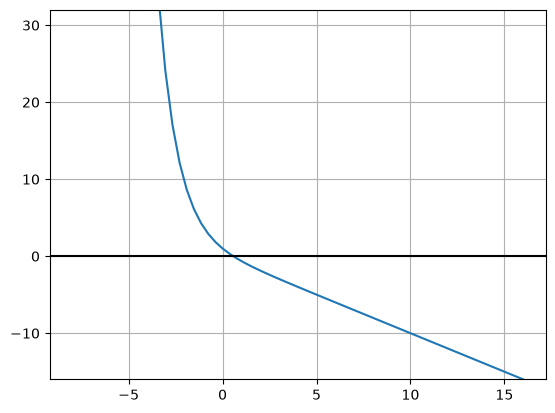

In [3]:
x = np.linspace(-(1 << 3), 1 << 4, 1 << 6)
y = f1(x)

plt.plot(x, y)
plt.axhline(0, color='black')
plt.grid(True)
plt.ylim(-(1 << 4), 1 << 5)
plt.show()

In [4]:
f1(0)

np.float64(1.0)

In [5]:
f1(1)

np.float64(-0.6321205588285577)

quite positive $(0, 1)$ is the bound

for `max_iter`, we set the base amount to 52, according to $e_\text{mach}$ of IEEE 754 double precision of $2^{-52} \approx 2.22\times10^{-16}$, then, add up that amount by the magnitude of our selected bound. And note on `tolerance`, i think $10^{-6}$ is for single precision float, so i'll do $10^{-14}$ throughout this assignment, if possible.

In [6]:
def bisection(function, left, right, tolerance = 1e-14, max_iter = 52):
    max_iter += int(np.ceil(np.log2(right - left)))

    a, b = left, right
    
    for _ in range(max_iter):
        m = (a + b) / 2

        fa = function(a)
        fm = function(m)

        if (fm == 0):
            return m
    
        if (fa > 0 and fm < 0) or (fa < 0 and fm > 0):
            b = m
        else:
            a = m

        if (abs(a - b) < tolerance):
            break

    return (a + b) / 2

In [7]:
bisection(f1, 0, 1)

0.5671432904097848

In [8]:
f1(bisection(f1, 0, 1))

np.float64(-1.5543122344752192e-15)

---
## Problem 2

Find all values of $x$ in $[0, 1]$ such that $f(x) = 0$, where

$$
f(x) = -0.000216747 + 0.0072868x - 0.0977383x^2 + 0.664685x^3 - 2.40773x^4 + 4.46766x^5 - 3.7091x^6 + x^7
$$

Your answers should be accurate to within $10^{-6}$ of the true solution.

In [9]:
def f(x):
    return -0.000216747 + 0.0072868*x - 0.0977383*x**2 + 0.664685*x**3 - \
            2.40773*x**4 + 4.46766*x**5 - 3.7091*x**6 + x**7


```text
Ps. With my current function naming scheme, i'll have to rename this given function `f` as `f2`, I will just copy it below.

In [10]:
def f2(x):
    return -0.000216747 + 0.0072868*x - 0.0977383*x**2 + 0.664685*x**3 - \
            2.40773*x**4 + 4.46766*x**5 - 3.7091*x**6 + x**7


first, i think it should be a nice idea to do coarse plot of this function first

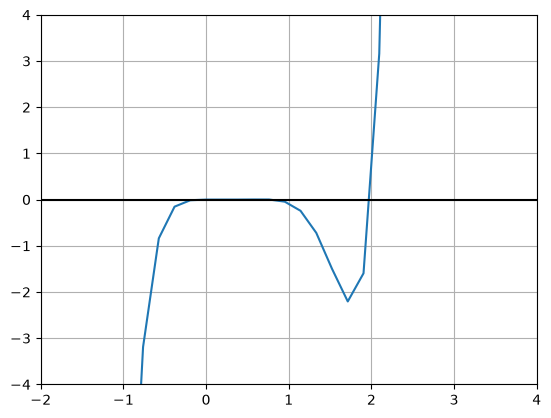

In [11]:
x = np.linspace(-(1 << 2), 1 << 3, 1 << 6)
y = f2(x)

plt.plot(x, y)
plt.axhline(0, color='black')
plt.grid(True)
plt.xlim(-(1 << 1), 1 << 2)
plt.ylim(-(1 << 2), 1 << 2)
plt.show()

we see that, in $[0, 1]$, it seems like the function intersect the x-axis somewhere in that boundary, maybe multiple intersection as well.

inspect more closely at $[-1, 1]$

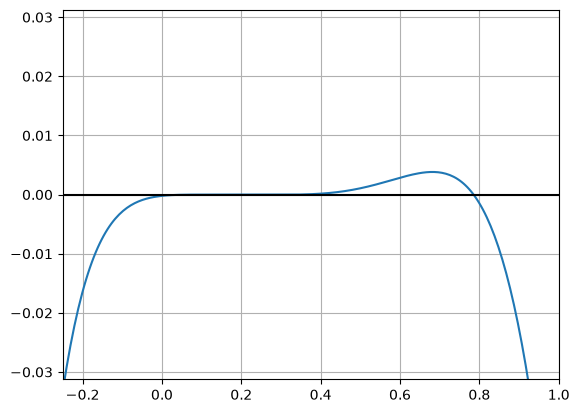

In [12]:
x = np.linspace(-1 / 4, 1 << 0, 1 << 8)
y = f2(x)

plt.plot(x, y)
plt.axhline(0, color='black')
plt.grid(True)
plt.xlim(-1 / 4, 1 << 0)
plt.ylim(-1 / 32, 1 / 32)
plt.show()

turns out, indeed the function is tricky, there's multiple intersection on x-axis. 

try using the bisection function from **problem 1**, on $[0, 1]$ (doesn't satisfy IVT, btw)

In [13]:
bisection(f2, 0, 1)

0.33329879874732526

In [14]:
f2(bisection(f2, 0, 1))

-6.884683795282953e-18

using the entire given range probably (surely) didn't work.

try checking from $-1/4$ to $1$, increment by $2^{-5}$, then use bisection whenever the sign changes, and use `np.isclose` to compare with the results we already have, so we don't count the same root twice.

In [15]:
bounds = np.arange(-1 / 4, 1 + 2**(-5), 2**(-5))
roots = []

for i in range(len(bounds) - 1):
    a = bounds[i]
    b = bounds[i + 1]

    if f2(a) * f2(b) > 0:
        continue

    root = bisection(f2, a, b)

    duplicate = False

    for previous in roots:
        if np.isclose(root, previous, atol=1e-14, rtol=0):
            duplicate = True
            break

    if not duplicate:
        roots.append(root)

for root in roots:
    if root < 0 or root > 1:
        continue

    print(f"x = {root:.14f}, f(x) = {f2(root):.6e}")

x = 0.12216651342345, f(x) = -1.768181e-19
x = 0.22002828210147, f(x) = 3.997996e-19
x = 0.33329879874733, f(x) = -6.884684e-18
x = 0.78540906264845, f(x) = -2.775558e-16


So, there were 4 roots for this function, within the boumd of $[0, 1]$

2.1) Find all local minima and maxima of the function $f(x)$ defined above. Briefly explain how you determine whether a point is a local maximum or minimum.

find the first and second derivative of the function first

the first derivative is

$$
f'(x) = 0.0072868 - 0.1954766x + 1.994055x^2 - 9.63092x^3 + 22.3383x^4 - 22.2546x^5 + 7x^6
$$

In [16]:
def df2(x):
      return (0.0072868 - 0.1954766*x + 1.994055*x**2
              - 9.63092*x**3 + 22.3383*x**4
              - 22.2546*x**5 + 7*x**6)

the second derivative is

$$
f''(x) = -0.1954766 + 3.98811x - 28.89276x^2 + 89.3532x^3 - 111.273x^4 + 42x^5$$

In [17]:
def ddf2(x):
      return (-0.1954766 + 3.98811*x - 28.89276*x**2
              + 89.3532*x**3 - 111.273*x**4 + 42*x**5)

the function 'peak' is where the slope is 0, which is where $f'(x) = 0$. 

we plot $f2'(x)$ out briefly to see roughly where all the peak was first. 

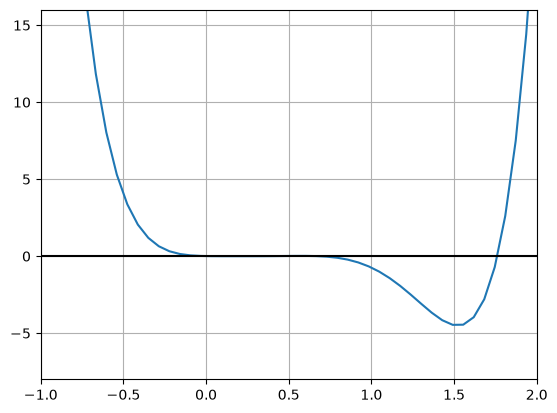

In [18]:
x = np.linspace(-(1 << 1), 1 << 1, 1 << 6)
y = df2(x)

plt.plot(x, y)
plt.axhline(0, color='black')
plt.grid(True)
plt.xlim(-(1 << 0), 1 << 1)
plt.ylim(-(1 << 3), 1 << 4)
plt.show()

zoom in at $[-0.5, 1]$, as the previous part proven to be tricky

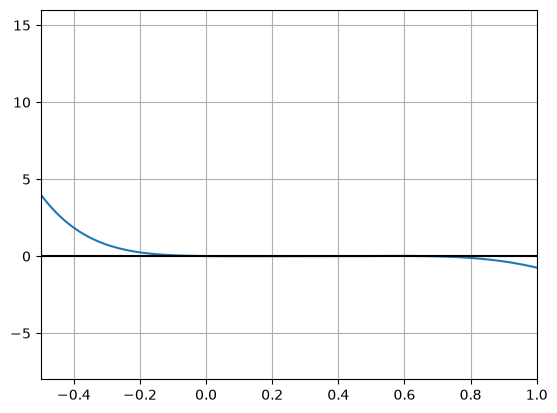

In [19]:
x = np.linspace(-0.5, 1 << 0, 1 << 7)
y = df2(x)

plt.plot(x, y)
plt.axhline(0, color='black')
plt.grid(True)
plt.xlim(-0.5, 1 << 0)
plt.ylim(-(1 << 3), 1 << 4)
plt.show()

and ... see nothing. there seems to be at least 2 x-intersection, which is according to our $f(x)$ plot above, where there seems to be at least 2 'peak'. 

we'll have to do use the same technique as the last part to check for all the root of first order derivative of this function at $[-0.5, 1]$

In [20]:
bounds = np.arange(-0.5, 1 + 2**(-5), 2**(-5))
roots = []

for i in range(len(bounds) - 1):
    a = bounds[i]
    b = bounds[i + 1]

    if df2(a) * df2(b) > 0:
        continue

    root = bisection(df2, a, b)

    duplicate = False

    for previous in roots:
        if np.isclose(root, previous, atol=1e-14, rtol=0):
            duplicate = True
            break

    if not duplicate:
        roots.append(root)

for root in roots:
    if root < 0 or root > 1:
        continue

    print(f"x = {root:.14f}, f'(x) = {df2(root):.6e}, f(x) = {f2(root):.14f}")

x = 0.19136723239373, f'(x) = 1.160096e-17, f(x) = 0.00000136907620
x = 0.29709131520985, f'(x) = 6.071532e-17, f(x) = -0.00001214713660
x = 0.68178052173565, f'(x) = 1.887379e-15, f(x) = 0.00382580832198


and for bound of $[1.2, 2]$, there should be another root of

In [21]:
bisection(df2, 1.2, 2)

1.7620816855389076

In [22]:
df2(bisection(df2, 1.5, 2))

-1.1368683772161603e-13

In [23]:
f2(bisection(df2, 1.5, 2))

-2.2526288451015333

we don't know yet whether this two point is local minima or maxima, as a lot of them are cluttered in a small range. 

Using second order derivative to check for local minima or local maxima

In [24]:
[ddf2(root) for root in roots]

[np.float64(-0.002629326982389074),
 np.float64(0.012574878797316863),
 np.float64(-0.4447252847344272)]

which means, the point of $(0.19136723239373, 0.00000136907620)$ and $(0.68178052173565, 0.00382580832198)$ is the local maxima, and point $(0.29709131520985, -0.00001214713660)$ is local minima

In [25]:
ddf2(bisection(df2, 1.5, 2))

46.723516860211475

and point $(1.7620816855389059, -2.2526288451015333)$ is the local minima

2.2) Identify the global maximum and global minimum of the function $f(x)$ within the interval $x \in [0, 1]$.

for global max and min inside $[0, 1]$, we compare the local minima and maxima in that area with the boundary as well. the largest function value is the global max, and the smallest is the global min.

In [26]:
candidates = [0]

for point in roots:
    if 0 < point and point < 1:
        candidates.append(point)

candidates.append(1)

values = []

for x_pos in candidates:
    val = f2(x_pos)
    values.append(val)

for i in range(len(candidates)):
    x_pos = candidates[i]
    val = values[i]

    print(f"x = {x_pos:.14f}, f(x) = {val:.14f}")

min_index = np.argmin(values)
max_index = np.argmax(values)

min = candidates[min_index]
max = candidates[max_index]

print(f"global min: ({min:.14f}, {f2(min):.14f})")
print(f"global max: ({max:.14f}, {f2(max):.14f})")

x = 0.00000000000000, f(x) = -0.00021674700000
x = 0.19136723239373, f(x) = 0.00000136907620
x = 0.29709131520985, f(x) = -0.00001214713660
x = 0.68178052173565, f(x) = 0.00382580832198
x = 1.00000000000000, f(x) = -0.07515324700000
global min: (1.00000000000000, -0.07515324700000)
global max: (0.68178052173565, 0.00382580832198)


---
## Problem 3: Bound States in a Finite Potential Well
In quantum physics, the bound state energies for a finite potential well are found by solving the following equation (where $E$ is negative):

$$
\sqrt{\frac{-E}{E+V_0}} = \tan \left( \sqrt{2m \frac{E+V_0}{\hbar^2} a} \right)
$$

Your task is to find all energy values $E$ that satisfy this equation.
For this problem, use the following simplified parameters (natural units):
- $V_0 = 1$
- $m = 1$
- $a = 1$
- $\hbar = 1$

This reduces the equation to:

$$
\sqrt{\frac{-E}{E+1}} = \tan \left( \sqrt{2(E+1)} \right)
$$

Instructions:
- Find all values of $E$ in the interval $(-1.0, 0)$ that satisfy the equation above.
- Your answers should be accurate to within $\pm 10^{-4}$.
- Briefly describe your numerical approach (e.g., root-finding method) before providing any code.


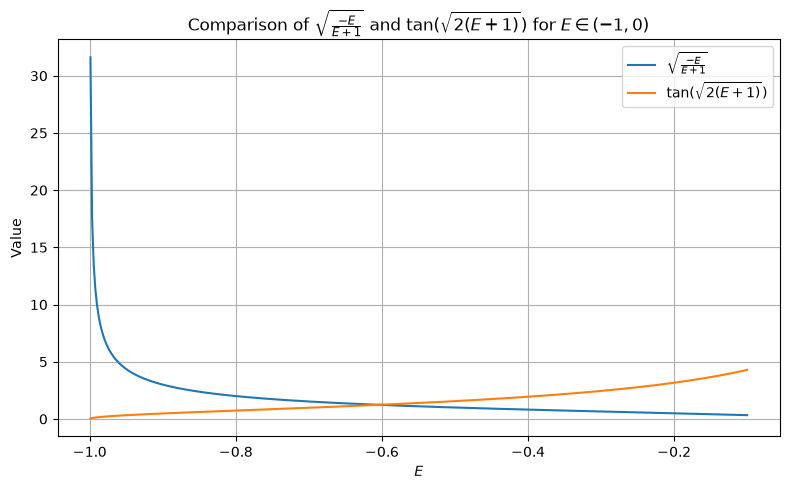

In [27]:
# Plot the functions for Problem 3
def f(x):
    return math.sqrt(-x/(x+1))
def g(x):
    return math.tan(math.sqrt(2*(x + 1)))

xs = np.linspace(-0.999, -0.1, 400)
fx = [f(x) for x in xs]
gx = [g(x) for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, fx, label=r'$\sqrt{\frac{-E}{E+1}}$')
plt.plot(xs, gx, label=r'$\tan(\sqrt{2(E+1)})$')
plt.xlabel(r'$E$')
plt.ylabel('Value')
plt.title(r'Comparison of $\sqrt{\frac{-E}{E+1}}$ and $\tan(\sqrt{2(E+1)})$ for $E \in (-1, 0)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

rearrange the simplified equation to

$$h(E)=\sqrt{\frac{-E}{E+1}}-\tan\left(\sqrt{2(E+1)}\right)=0$$

In [28]:
def h3(x) -> float: 
    return math.sqrt(-x/(x+1)) - math.tan(math.sqrt(2*(x + 1)))

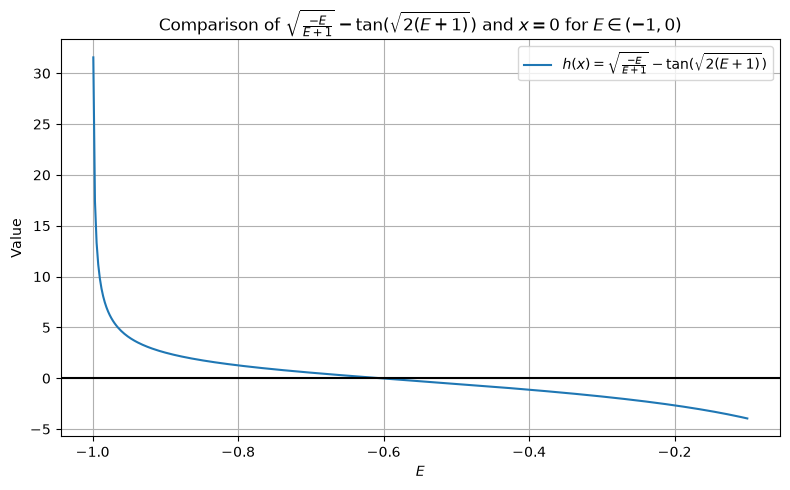

In [29]:
# Plot the functions for Problem 3
xs = np.linspace(-0.999, -0.1, 400)
hx = [h3(x) for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, hx, label=r'$h(x) = \sqrt{\frac{-E}{E+1}} - \tan(\sqrt{2(E+1)})$')
plt.axhline(0, color='black')
plt.xlabel(r'$E$')
plt.ylabel('Value')
plt.title(r'Comparison of $\sqrt{\frac{-E}{E+1}} - \tan(\sqrt{2(E+1)})$ and $x = 0$ for $E \in (-1, 0)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

the plot seems to only be decreasing, and so, there's should be a single intersection of $h(x)$ to the x axis, with positive value on the left side and negative value on the right. 

Using the bound of $[-0.8, -0.4]$ (or $[-0.\dot{9}, 0.0]$ should work as well), we could use our bisection method or root finding from **problem 1** to find that intersection point. 

In short, the bisection method works on the promise of the **intermediate value theorem** (IVT) that for continuous bound of $(a, b) \to (f(a), f(b))$, for any $y \in (f(a), f(b))$ there exist $c \in (a, b)$ where $f(c) = y$, in this case, we want $f(c) = 0$, so f(a) and f(b) should have opposite sign. We use this as an existance test, then squeeze the boundary with something representing binary search or divide an conqure technique.

In [30]:
bisection(h3, -0.8, -0.4)

-0.603897833863394

In [31]:
h3(bisection(h3, -0.8, -0.4))

-2.6645352591003757e-15

---

## Problem 4
Suppose Alex quit programming and decided to become an apple (fruit) shop owner. Alex buys 1000 apples every day and tries to sell them. The probability that $k$ customers want Alex's apples (one each) is given by the Poisson distribution:

$$
    P(k; \lambda) = \frac{\lambda^k \exp(-\lambda)}{k!}
$$

Where $\lambda$ is a parameter that represents the mean number of people who want Alex's apples each day.

After selling apples for 2000 days, Alex found that all 1000 apples were sold out on 600 days out of 2000 days.

The goal for this problem is to figure out how Alex should change the number of apples bought each day.

- In case you are curious: https://en.wikipedia.org/wiki/Poisson_distribution. The true distribution of this selling apple process should be binomial distribution, but with a large enough number of customers and a low enough probability of an individual buying an apple, this is an excellent approximation.

4.1) You may find that if you try to code the Poisson distribution directly, it will not work with large numbers.
$$
    P(k; \lambda) = \frac{\lambda^k \exp(-\lambda)}{k!}
$$

Explain briefly why Python complains when Alex tries to compute this for large $k$ and $\lambda$.

In [32]:
import math

def bad_poisson(lmd, k):
	return pow(lmd, k) * math.exp(-lmd) / math.factorial(k)

# bad_poisson(1000, 1000)  # Uncomment to see it breaks

---------------------------------------------------------------------------
OverflowError                             Traceback (most recent call last)
Cell In[183], line 1
----> 1 bad_poisson(1000, 1000)

Cell In[5], line 4, in bad_poisson(lmd, k)
      3 def bad_poisson(lmd, k):
----> 4         return pow(lmd, k) * math.exp(-lmd) / math.factorial(k)

OverflowError: int too large to convert to float

floating point overflow i supposed, and python don't allow that.

4.2) A very useful trick to avoid this problem is to take the logarithm of the Poisson formula and then exponentiate. That is,

$$
    P(k; \lambda) = \exp\left( \ln \left[ \frac{\lambda^k \exp(-\lambda)}{k!} \right] \right)
$$

First, show that
$$
    \ln(P(k; \lambda)) = (\ldots \ln(\ldots)-\ldots)-\ln(k!)
$$

Write out the steps to derive this result from the original formula.

take natural log on both side of the equation as

$$\ln(P(k; \lambda)) = \ln\left(\frac{\lambda^k \exp(-\lambda)}{k!}\right) = \ln(\lambda^k \exp(-\lambda)) - \ln(k!)$$

or 

$$\ln(\lambda^k \exp(-\lambda)) - \ln(k!) = \ln(\lambda^k) + \ln(\exp(-\lambda)) - \ln(k!) = (k\ln(\lambda) -(\lambda)\ln(e)) - \ln(k!) = \boxed{(k\ln(\lambda) -\lambda) - \ln(k!)}$$

I think of it as, which exponent of euler's constant gives $P(k; \lambda)$, of which that exponent is $\ln(\lambda^k \exp(-\lambda)) - \ln(k!)$. So

$$\exp(\ln(\lambda^k \exp(-\lambda)) - \ln(k!)) = \boxed{P(k; \lambda) = \exp((k\ln(\lambda) -\lambda) - \ln(k!))}$$

4.3) The term $\ln(k!)$ appears frequently in mathematics and statistics. Most math libraries provide a fast way to compute this using the `lgamma` function, which gives $\ln((k-1)!)$.

For example:

`math.lgamma(5) == math.log(math.factorial(4))`

Your task: Implement $P(k; \lambda)$ using the log-exp trick described above, and use `math.lgamma` to handle the factorial term efficiently.

If you do it correctly, you should find $P(k=1000; \lambda=1000) \approx 0.0126146$.

In [33]:
def P4(k, l) -> float:
    return np.exp(k * np.log(l) - l - math.lgamma(k + 1))

In [34]:
P4(1000, 1000)

np.float64(0.012614611348719664)

4.4) Now for a practical challenge. Suppose $\lambda = 987.6$ (note: this is just an example value). Find the probability that Alex will sell all 1000 apples in a day. (Remember, if 1000 or more people want Alex's apples, all apples will be sold out.)

Hint: You do not need to sum the Poisson probabilities to infinity—find a practical way to compute this probability efficiently.

$P(k; \lambda)$ gives the probably that $k$ customer buy the apple, so in this case, we want $P(k) \ge 1000$.

But, that'd means we'd have to iterate from 1000 to $\infty$, impossible. So, using the complement rule, 

$$P(k \ge 1000) = 1 - P(k < 1000)$$

and now, our loop is finite and is fairly small

In [35]:
LAMBDA4 = 987.6
complement_probability_sum = 0.0

for k in range(0, 1000):
    complement_probability_sum += P4(k, LAMBDA4)

print(1 - complement_probability_sum)

0.35078465816698645


4.5) Recall the information:

After selling apples for 2000 days, Alex found that all 1000 apples were sold out on 600 days out of 2000 days.

Estimate the value of $\lambda$ (the average number of customers per day) to a reasonable accuracy ($<\pm 0.1$) that matches this observation.

we're given

$$P(K \ge 1000; \lambda) = \frac{600}{2000} = 0.3$$

using the complement rule again, we got

$$P(K < 1000; \lambda) = 1 - 0.3 = 0.7$$

so, we use the same sum from the previous part, but this time, let $\lambda$ change until the sum is $0.7$. rearrange it to

$$Q(\lambda) = \sum_{k=0}^{999} P(k; \lambda) - 0.7 = 0$$

In [36]:
def Q4(l):
    complement_probability_sum = 0.0

    for k in range(0, 1000):
        complement_probability_sum += P4(k, l)

    return complement_probability_sum - 0.7

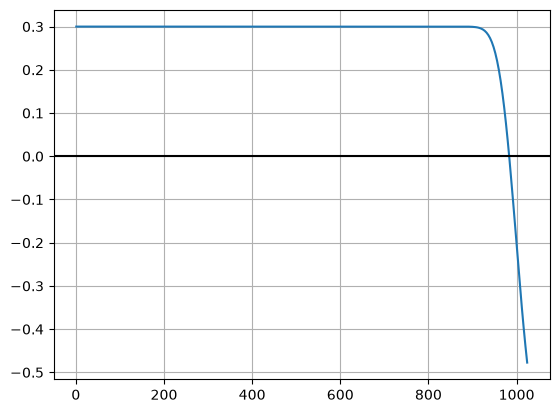

In [37]:
x = np.linspace(1, 1 << 10, 1 << 8)
y = Q4(x)

plt.plot(x, y)
plt.axhline(0, color='black')
plt.grid(True)
plt.show()

So, the root of $Q(\lambda)$ should be around $(900, 1000)$

In [38]:
Q4(900)

np.float64(0.2994500977344029)

In [39]:
Q4(1000)

np.float64(-0.20420524418027647)

In [40]:
bisection(Q4, 900, 1000)

983.1784467579032

In [41]:
Q4(bisection(Q4, 900, 1000))

np.float64(-1.176836406102666e-13)

4.6) Using the $\lambda$ you found in 4.5:

Alex buys apples for 20 Baht each and sells them for 50 Baht each. This means Alex makes a profit of 30 Baht for every apple sold. At the end of each day, any unsold apples are thrown away, resulting in a loss of 20 Baht per unsold apple.

If Alex buys 1000 apples a day, what would be his expected profit? (Remember to use the concept of expected value from discrete math/statistics.)

if $k < 1000$ customers come, we sell $k$ apples and throw away $1000-k$ apples. so the profit is

$$30k - 20(1000-k) = 50k - 20000$$

if $k \ge 1000$, we sell all the apples, so the profit is $30000$ Baht. multiply each profit by its probability, then add them up:

$$\mathbb{E}[\text{profit}] = \sum_{k=0}^{999}(50k-20000)P(k;\lambda) + 30000\left(1-\sum_{k=0}^{999}P(k;\lambda)\right)$$

In [42]:
LAMBDA4 = bisection(Q4, 900, 1000)
expected_profit = 0.0
complement_probability_sum = 0.0

for k in range(0, 1000):
    probability = P4(k, LAMBDA4)
    profit = 50 * k - 20000
    expected_profit += profit * probability
    complement_probability_sum += probability

sold_out_probability = 1 - complement_probability_sum
expected_profit += 30000 * sold_out_probability

print(expected_profit)

28864.606141774315


4.7) Using the $\lambda$ you found in 4.5, determine the optimal number of apples Alex should buy each day to maximize expected profit.

In [43]:
# start from k = 1000 that the previous part of this question gave us, as the probability seems decent already
k = 1000

profit = 0.0
probability_sum = 0.0

for i in range(k):
    probability = P4(i, LAMBDA4)
    profit += (50 * i - 20 * k) * probability
    probability_sum += probability

profit += 30 * k * (1 - probability_sum)

# check for direction that increase the profit, or we could plot out the graph and manually inspect
next_profit = 0.0
probability_sum = 0.0

for i in range(1001):
    probability = P4(i, LAMBDA4)
    next_profit += (50 * i - 20 * 1001) * probability
    probability_sum += probability

next_profit += 30 * 1001 * (1 - probability_sum)

if next_profit > profit:
    direction = 1
else:
    direction = -1

# then search until the profit stops increasing
while (True):
    next_k = k + direction

    next_profit = 0.0
    probability_sum = 0.0

    for i in range(next_k):
        probability = P4(i, LAMBDA4)
        next_profit += (50 * i - 20 * next_k) * probability
        probability_sum += probability

    next_profit += 30 * next_k * (1 - probability_sum)

    if next_profit <= profit:
        break

    k = next_k
    profit = next_profit

print("optimal number of apples: ", k)
print("expected daily profit (thb): ", profit)

optimal number of apples:  991
expected daily profit (thb):  28888.896089723065


---

## Problem 5

Full Width at Half Maximum (FWHM) is an important measure of distribution width. It tells you how wide a distribution is at half of its maximum value. FWHM is commonly used in physics, statistics, and signal processing to characterize the spread of a peak or distribution.

For example, consider the distribution shown below, where the maximum occurs at $x = 0.0$ and $y = 1.0$.

The maximum value of this distribution is 1.0, so we are interested in the width of the distribution where its value is $1.0/2 = 0.5$.

The FWHM is illustrated by the black line in the plot. In this case, it's about 2.35 units wide.

Your tasks in this problem will involve calculating and analyzing the FWHM for different functions and parameters.

Text(0, 0.3, 'FWHM')

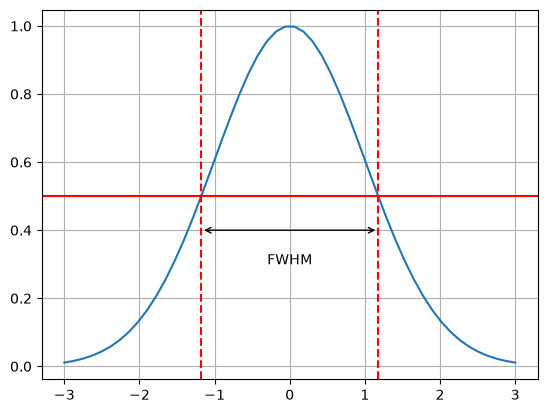

In [44]:
import math

def demo(x):
	return math.exp(-x**2 / 2.0)

# Generate data
x = np.linspace(-3, 3)
y = [demo(xx) for xx in x]

# Plot the distribution
plt.plot(x, y)
plt.axhline(0.5, color='red')
plt.axvline(2.355 / 2, color='red', linestyle='dashed')
plt.axvline(-2.355 / 2, color='red', linestyle='dashed')
plt.grid()
plt.annotate('', xy=(-2.355 / 2, 0.4), xycoords='data', xytext=(2.355 / 2, 0.4), textcoords='data', arrowprops={'arrowstyle': '<->'})
plt.text(0, 0.3, 'FWHM', horizontalalignment='center')

5.1) Find the FWHM (full width at half maximum) of the following function:

$$
    f(x, \gamma) = \frac{\gamma}{(x - \mu)^2 + \gamma^2}
$$
where $\mu = 2.345$ and $\gamma = 3.1$.

Make sure your answer for the FWHM has an error less than $10^{-4}$.

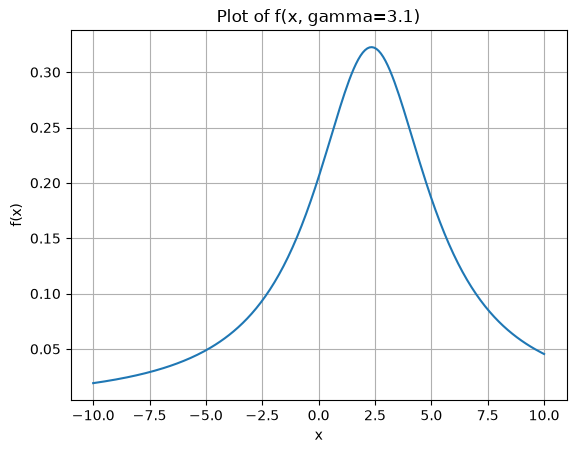

In [45]:
import math

def f(x, gamma=3.1):
	mu = 2.345
	return gamma / ((x - mu) ** 2 + gamma ** 2)

# Generate data
x = np.linspace(-10, 10, 200)
y = [f(xx) for xx in x]

# Plot the function

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of f(x, gamma=3.1)')
plt.grid(True)

In [46]:
import math

def f5(x, gamma=3.1):
	mu = 2.345
	return gamma / ((x - mu) ** 2 + gamma ** 2)

first, find the first derivative with respect to $x$, treating $\mu$ and $\gamma$ as constants:

$$f(x) = \gamma\left((x-\mu)^2+\gamma^2\right)^{-1}$$

$$f'(x) = -\gamma\left((x-\mu)^2+\gamma^2\right)^{-2}\cdot 2(x-\mu) = \frac{-2\gamma(x-\mu)}{\left((x-\mu)^2+\gamma^2\right)^2}$$

In [47]:
def df5(x, gamma=3.1):
    mu = 2.345
    return -2 * gamma * (x - mu) / ((x - mu) ** 2 + gamma ** 2) ** 2

use bisection to find where $f'(x)=0$. the derivative is positive before that point and negative after it, so this is the maximum. then plug that $x$ back into $f$ to get the peak height.

2.3450000000000015
0.3225806451612903


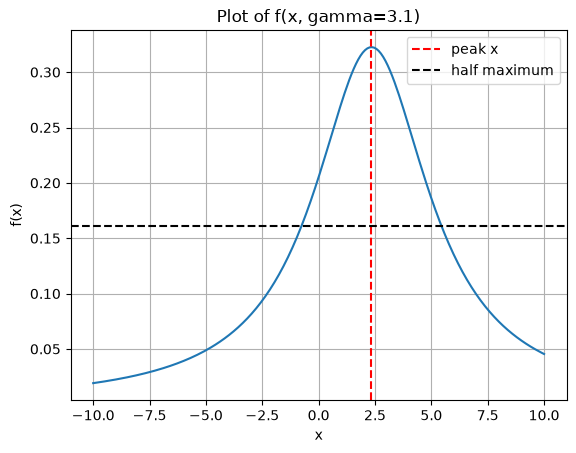

In [48]:
# find the peak position, then its height
x_max = bisection(df5, 0.0, 5.0)
print(x_max)
y_max = f5(x_max)
print(y_max)

# Generate data
x = np.linspace(-10, 10, 200)
y = [f5(xx) for xx in x]

# Plot the function
plt.figure()
plt.plot(x, y)
plt.axvline(x_max, color='red', linestyle='dashed', label='peak x')
plt.axhline(y_max / 2, color='black', linestyle='dashed', label='half maximum')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of f(x, gamma=3.1)')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
y_max / 2

0.16129032258064516

we now would have to find the two intersection between $y = 0.16129032258064516$ and $f(x)$, which is where $f(x) = 0.16129032258064516$. 

Move the constant to the left, we got $g(x) = f(x) - 0.16129032258064516 = 0$ --- this now can be solved with our root finding algorithm, and we should use the boundary at $[-2.5, 0]$ and $[5, 7.5]$

In [50]:
def g5(x): 
    return f5(x) - (y_max / 2)

In [51]:
bisection(g5, -2.5, 0.0)

-0.7550000000000034

In [52]:
g5(bisection(g5, -2.5, 0.0))

-1.942890293094024e-16

In [53]:
bisection(g5, 5, 7.5)

5.444999999999998

In [54]:
g5(bisection(g5, 5, 7.5))

1.3877787807814457e-16

Both $-0.7550000000000034 \approx -0.755$ and $5.444999999999998 \approx 5.445$ gives a very small residue. I round it to around 3-4 significance figures as the input $\mu$ and $\gamma$ only contain 2 and 4 significance figures. 

Then, FWHM should be defined by the difference between these two intersections, so 

In [55]:
abs(bisection(g5, -2.5, 0.0) - bisection(g5, 5, 7.5))

6.200000000000001

5.2) Plot the FWHM (y-axis) as a function of $\gamma$ for the function $f(x, \gamma)$, where $\gamma$ ranges from $0.5$ to $3.0$. Make sure your plot includes at least 30 points for $\gamma$ values.

In [56]:
print(f(1.0, gamma=0.2)) # you may find this useful

0.1081651140465921


I guess i should try a few more values? 

In [57]:
print(f(1.0, gamma=0.5)) # you may find this useful

0.24283337987639775


In [58]:
print(f(1.0, gamma=1.5)) # you may find this useful

0.3695468739414022


In [59]:
print(f(1.0, gamma=3)) # you may find this useful

0.2775458471046186


In [60]:
print(f(1.0, gamma=5)) # you may find this useful

0.18650435814058883


same as **5.1**, but repeat it for different $\gamma$ values instead of $\mu$. for each one, find the peak, divide its height by 2, then find the two intersections and take their difference.

we use $2^5 = 32$ values from $0.5$ to $3.0$. the intersections move as $\gamma$ changes, so use loose bound as $[-2.5, x_{\max}]$ and $[x_{\max}, 7.5]$ to keep one intersection in each bound.

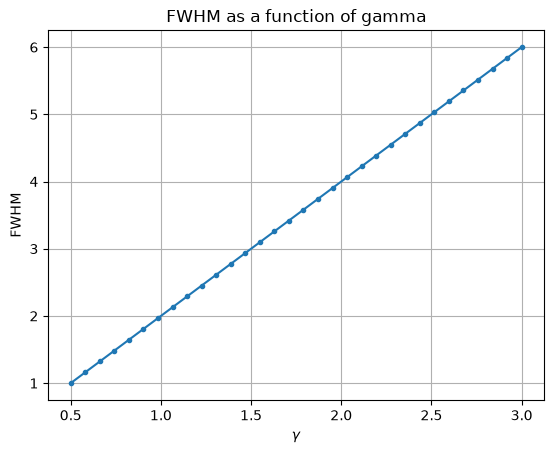

In [61]:
gammas = np.linspace(0.5, 3.0, 1 << 5)
fwhm = []

for gamma in gammas:
    def df5_gamma(x):
        return df5(x, gamma=gamma)

    # find the peak position, then its height
    x_max = bisection(df5_gamma, 0.0, 5.0)
    y_max = f5(x_max, gamma=gamma)

    # move half the peak height to the left, same as 5.1
    def g5_gamma(x):
        return f5(x, gamma=gamma) - (y_max / 2)

    x_left = bisection(g5_gamma, -2.5, x_max)
    x_right = bisection(g5_gamma, x_max, 7.5)

    width = abs(x_left - x_right)
    fwhm.append(width)

# plot
plt.figure()
plt.plot(gammas, fwhm, marker='.')
plt.xlabel(r'$\gamma$')
plt.ylabel('FWHM')
plt.title('FWHM as a function of gamma')
plt.grid(True)
plt.show()

5.3) (Optional) Prove the mathematical relationship between FWHM and $\gamma$ for the function $f(x, \gamma)$. Show your derivation and explain why the FWHM depends on $\gamma$ in the way observed in your plot from 5.2.

same as **5.1**, first find the maximum height. for $\gamma > 0$, the numerator is positive and constant with respect to $x$, so the function is largest when the denominator is smallest. since $(x-\mu)^2 \ge 0$, this happens at $x=\mu$.

$$f_{\max}=f(\mu,\gamma)=\frac{\gamma}{(\mu-\mu)^2+\gamma^2}=\frac{\gamma}{\gamma^2}=\frac{1}{\gamma}$$

then, find the two intersections at half that height:

$$f(x,\gamma)=\frac{f_{\max}}{2}=\frac{1}{2\gamma}$$

substitute the function, then cross multiply:

$$\frac{\gamma}{(x-\mu)^2+\gamma^2}=\frac{1}{2\gamma}$$

$$2\gamma^2=(x-\mu)^2+\gamma^2$$

subtract $\gamma^2$ from both sides, then take both square-root possibilities. since $\gamma>0$:

$$(x-\mu)^2=\gamma^2$$

$$x-\mu=\pm\gamma$$

$$x_{\text{left}}=\mu-\gamma,\qquad x_{\text{right}}=\mu+\gamma$$

Then, FWHM is the difference between these two intersections, so

$$\mathrm{FWHM}=x_{\text{right}}-x_{\text{left}}=(\mu+\gamma)-(\mu-\gamma)=\boxed{2\gamma}$$

so, the plot in **5.2** is a straight line with slope 2. doubling $\gamma$ doubles the width, while $\mu$ only shifts the peak and doesn't change the width. for **5.1**, $\gamma=3.1$ gives $\mathrm{FWHM}=2(3.1)=6.2$, which matches our result.

<!-- QED. -->
<div style="text-align: right;">■</div>